***Exploratory Data Analysis On Zomato Dataset***

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [132]:
df = pd.read_csv("Indian-Resturants.csv")

In [133]:
df.head(2)

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1


**Data Overview**

In [134]:
df.shape

(211944, 26)

- Data contains 211944 rows and 26 columns

In [135]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

- **Restaurant ID** → Unique identifier for each restaurant  
- **Restaurant Name** → Name of the restaurant  
- **Country Code** → Code representing the country location  
- **City** → City where the restaurant is located  
- **Address** → Full address of the restaurant  
- **Locality** → Specific area within the city  
- **Locality Verbose** → Detailed description of the locality  
- **Longitude** → Geographical longitude coordinate  
- **Latitude** → Geographical latitude coordinate  
- **Cuisines** → Types of food served by the restaurant  
- **Average Cost for two** → Approximate cost for two people  
- **Currency** → Currency used in the restaurant  
- **Has Table booking** → Indicates if table booking is available (Yes/No)  
- **Has Online delivery** → Indicates if online delivery is available (Yes/No)  
- **Is delivering now** → Whether the restaurant is currently delivering  
- **Switch to order menu** → Option to switch to online ordering menu  
- **Price range** → Cost category of the restaurant (e.g., low to high)  
- **Aggregate rating** → Overall rating of the restaurant  
- **Rating color** → Color representing rating category  
- **Rating text** → Text description of rating (e.g., Good, Excellent)  
- **Votes** → Number of user votes received  

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

- The dataset contains both **numerical (int, float)** and **categorical (object)** data types.  
- Most columns have **non-null values**, but some columns contain **missing data**.  
- Numerical columns include features like **cost, ratings, votes, latitude, and longitude**.  
- Categorical columns include **restaurant name, city, cuisines, and services**.  
- Data types are appropriate for analysis, but **some columns may require cleaning or conversion**.  

In [137]:
df = df.drop(columns=['res_id', 'url', 'address','city_id','latitude','longitude','country_id','opentable_support','locality','currency','zipcode','delivery','takeaway'])

In [138]:
df.columns
df.shape

(211944, 13)

In [139]:
df.isnull().sum()

name                       0
establishment              0
city                       0
locality_verbose           0
cuisines                1391
timings                 3874
average_cost_for_two       0
price_range                0
highlights                 0
aggregate_rating           0
rating_text                0
votes                      0
photo_count                0
dtype: int64

In [140]:
df.isnull().sum()[df.isnull().sum()>0]

cuisines    1391
timings     3874
dtype: int64

In [141]:
df['timings']=df['timings'].fillna('Not Available')

In [142]:
df['cuisines']=df['cuisines'].fillna('unknown')

In [143]:
df.isnull().sum()

name                    0
establishment           0
city                    0
locality_verbose        0
cuisines                0
timings                 0
average_cost_for_two    0
price_range             0
highlights              0
aggregate_rating        0
rating_text             0
votes                   0
photo_count             0
dtype: int64

In [144]:
print("Number of Duplicate enteries",df.duplicated().sum())

Number of Duplicate enteries 155500


In [145]:
df.drop_duplicates(inplace=True)

In [146]:
df.dtypes

name                     object
establishment            object
city                     object
locality_verbose         object
cuisines                 object
timings                  object
average_cost_for_two      int64
price_range               int64
highlights               object
aggregate_rating        float64
rating_text              object
votes                     int64
photo_count               int64
dtype: object

In [147]:
df.columns

Index(['name', 'establishment', 'city', 'locality_verbose', 'cuisines',
       'timings', 'average_cost_for_two', 'price_range', 'highlights',
       'aggregate_rating', 'rating_text', 'votes', 'photo_count'],
      dtype='object')

In [148]:
df.head(2)

,name,establishment,city,locality_verbose,cuisines,timings,average_cost_for_two,price_range,highlights,aggregate_rating,rating_text,votes,photo_count
0,Bikanervala,['Quick Bites'],Agra,"Khandari, Agra","North Indian, South Indian, Mithai, Street Foo...",8:30am – 10:30pm (Mon-Sun),700,2,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154
1,Mama Chicken Mama Franky House,['Quick Bites'],Agra,"Agra Cantt, Agra","North Indian, Mughlai, Rolls, Chinese, Fast Fo...","12:30PM to 12Midnight (Mon, Wed, Thu, Fri, Sat...",600,2,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161


**Univariate Analysis**

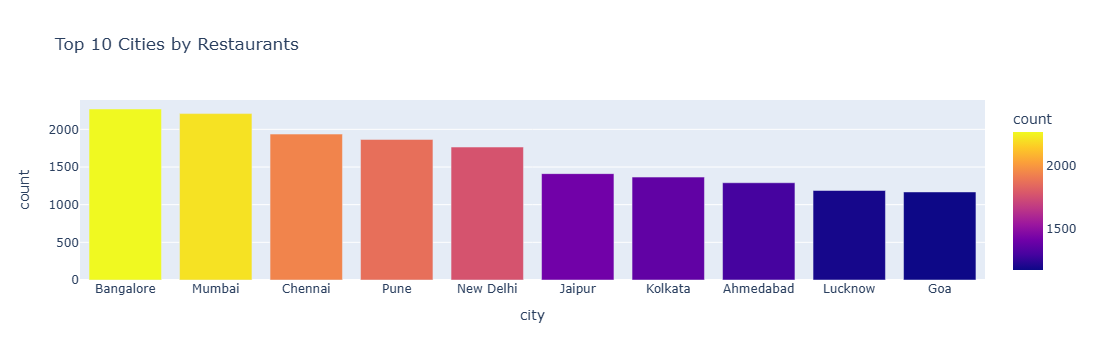

In [149]:
#Top cities
city_counts = df['city'].value_counts().head(10).reset_index()
city_counts.columns = ['city', 'count']
fig = px.bar(city_counts,x='city',y='count',title='Top 10 Cities by Restaurants',color='count')
fig.show()

- Bangalore has the highest number of restaurants, indicating a strong food market presence.
- Mumbai closely follows, showing high demand and competition in metropolitan cities.
- Chennai, Pune, and New Delhi also have a significant number of restaurants.
- Tier-2 cities like Jaipur, Kolkata, and Ahmedabad show moderate restaurant presence.
- Lucknow and Goa have comparatively fewer restaurants among the top cities.
- Overall, metro cities dominate the restaurant landscape, reflecting higher urban demand and population density.

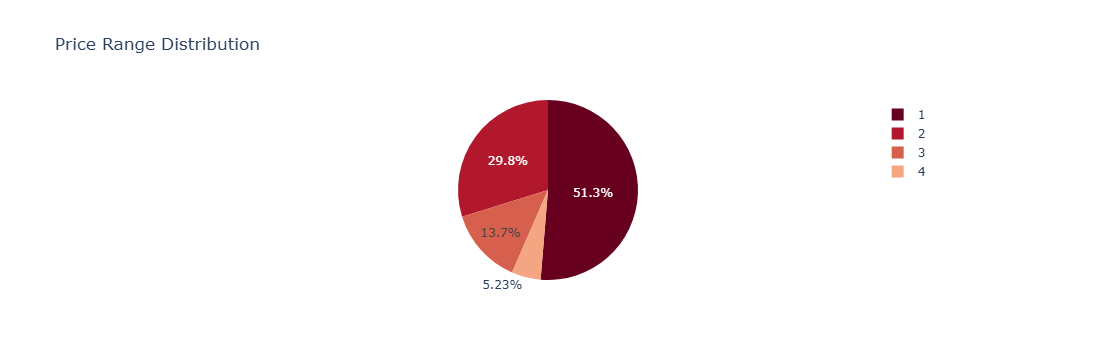

In [150]:
#price range
price_counts = df['price_range'].value_counts().reset_index()
price_counts.columns = ['price_range', 'count']
fig = px.pie(price_counts,names='price_range',values='count',title='Price Range Distribution',color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

- The majority of restaurants fall under **price range 1 (51.3%)**, indicating a strong presence of budget-friendly options.
- Price range 2 accounts for **29.8%**, showing a significant share of mid-range restaurants.
- Only **13.7%** of restaurants fall under price range 3, representing fewer premium options.
- Price range 4 has the smallest share (**5.23%**), indicating limited high-end or luxury restaurants.
- Overall, the dataset is dominated by **affordable and mid-range restaurants**, reflecting mass market demand.

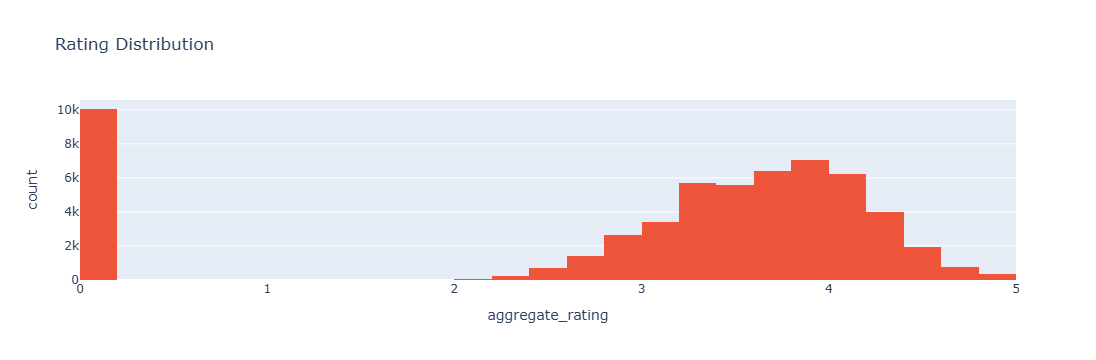

In [151]:
#rating
fig = px.histogram(df,x='aggregate_rating',nbins=30,title='Rating Distribution',color_discrete_sequence=['#EF553B'])
fig.show()

- Most restaurant ratings are concentrated between **3.0 and 4.5**, indicating generally good customer satisfaction.
- A peak is observed around **3.5 to 4.0**, suggesting this is the most common rating range.
- A significant number of restaurants have a rating of **0**, which may represent unrated or newly listed restaurants.
- Very few restaurants have ratings below **2.5**, indicating fewer poorly rated establishments.
- The distribution is slightly **left-skewed**, showing more restaurants with higher ratings.

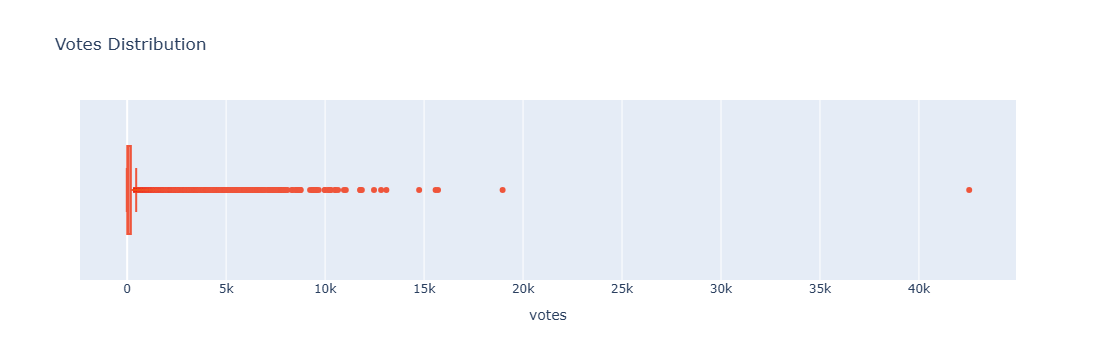

In [152]:
#votes
fig = px.box(df,x='votes',title='Votes Distribution',color_discrete_sequence=['#EF553B'])
fig.show()

- The distribution of votes is highly **right-skewed**, with most restaurants having very low vote counts.
- A small number of restaurants have extremely high votes, indicating **high popularity or visibility**.
- The majority of restaurants receive fewer than **1000 votes**, showing limited customer engagement for most.
- Presence of multiple **outliers** suggests a few restaurants dominate in terms of customer interactions.
- This indicates that popularity is concentrated among a small number of top-performing restaurants.

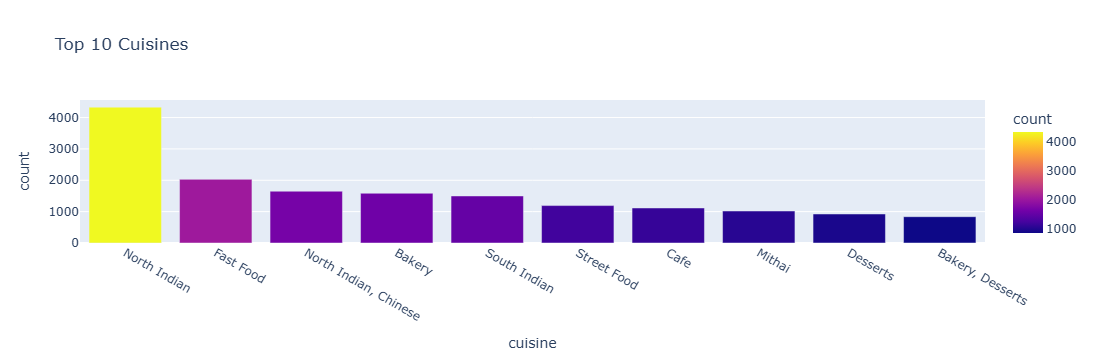

In [153]:
#cuisines
cuisine_counts = df['cuisines'].value_counts().head(10).reset_index()
cuisine_counts.columns = ['cuisine', 'count']
fig = px.bar(cuisine_counts,x='cuisine',y='count',title='Top 10 Cuisines',color='count',color_continuous_scale='plasma')
fig.show()

- **North Indian cuisine** dominates the dataset with the highest number of restaurants.
- Fast Food is the second most common cuisine, reflecting high demand for quick-service options.
- Combination cuisines like **North Indian + Chinese** are also popular among customers.
- South Indian, Bakery, and Street Food have a significant presence in the market.
- Café, Mithai, and Desserts represent niche but steady demand categories.
- Overall, **Indian cuisines dominate**, showing strong customer preference for local food options.

**BIVARIATE ANALYSIS**

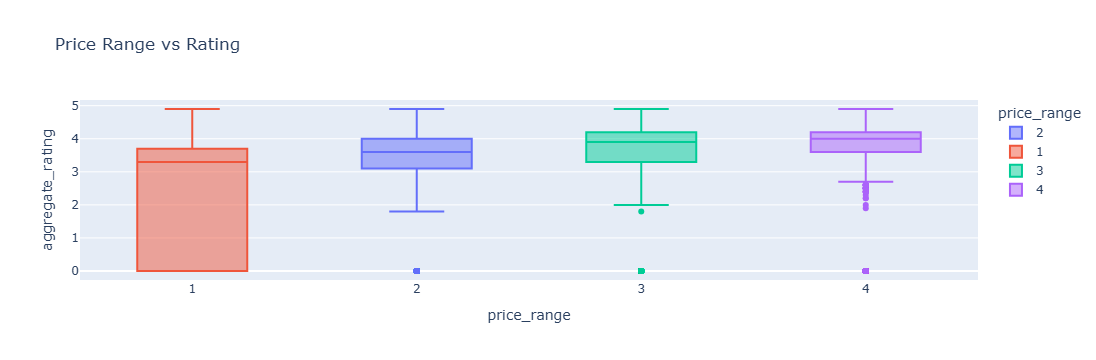

In [154]:
#Price range vs rating
fig = px.box(df,x='price_range',y='aggregate_rating',color='price_range',title='Price Range vs Rating')
fig.show()

- Ratings show a **slight increasing trend** as the price range increases.
- Higher price range restaurants (3 and 4) tend to have **better median ratings**.
- Lower price range (1) shows **higher variability**, including many low-rated restaurants.
- Most restaurants across all price ranges have ratings between **3.0 and 4.5**.
- Presence of outliers (including 0 ratings) exists in all price categories.
- Overall, **price has a mild impact on ratings**, but it is not a strong determining factor.

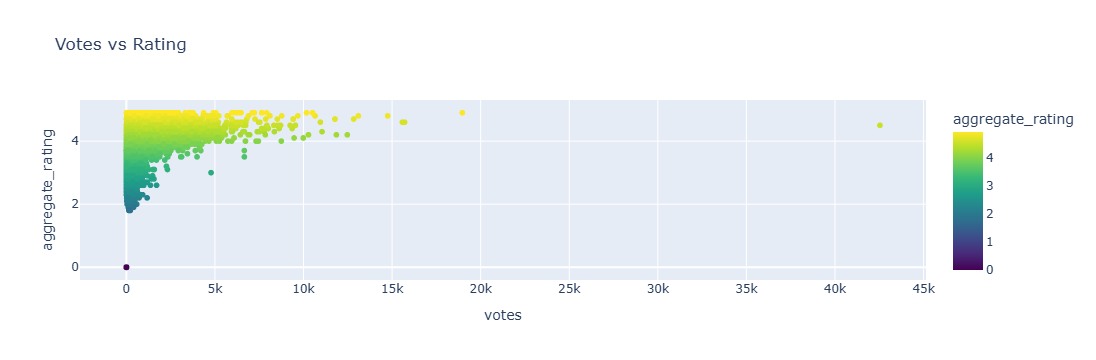

In [155]:
#votes vs rating
fig = px.scatter(df,x='votes',y='aggregate_rating',color='aggregate_rating',title='Votes vs Rating',color_continuous_scale='viridis')
fig.show()

- There is a **weak positive relationship** between votes and ratings.
- Restaurants with higher votes tend to have **slightly better ratings**, but the trend is not very strong.
- Most restaurants are clustered in the **low votes (0–5000) range**, regardless of rating.
- A few restaurants have extremely high votes, acting as **outliers with high popularity**.
- Ratings remain mostly between **3.0 and 4.5** across all vote levels.
- Overall, **votes indicate popularity but do not strongly determine ratings**.

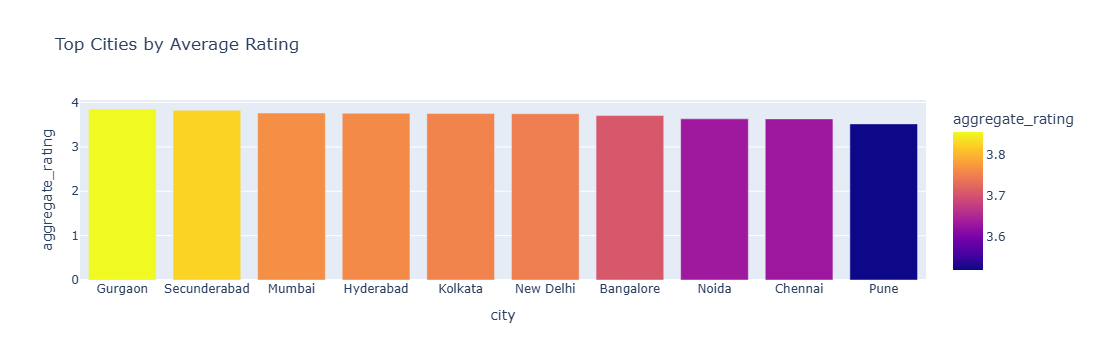

In [160]:
#city vs rating
city_rating = df.groupby('city')['aggregate_rating'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(city_rating,x='city',y='aggregate_rating',color='aggregate_rating',title='Top Cities by Average Rating',color_continuous_scale='plasma')
fig.show()

- Gurgaon has the highest average rating among all cities, indicating better overall customer satisfaction.
- Secunderabad and Mumbai also show relatively high average ratings.
- Hyderabad, Kolkata, and New Delhi have similar mid-range ratings.
- Bangalore, Noida, and Chennai have slightly lower average ratings compared to top cities.
- Pune has the lowest average rating among the top cities.
- Overall, the variation in ratings across cities is **not very large**, indicating consistent restaurant quality across locations.

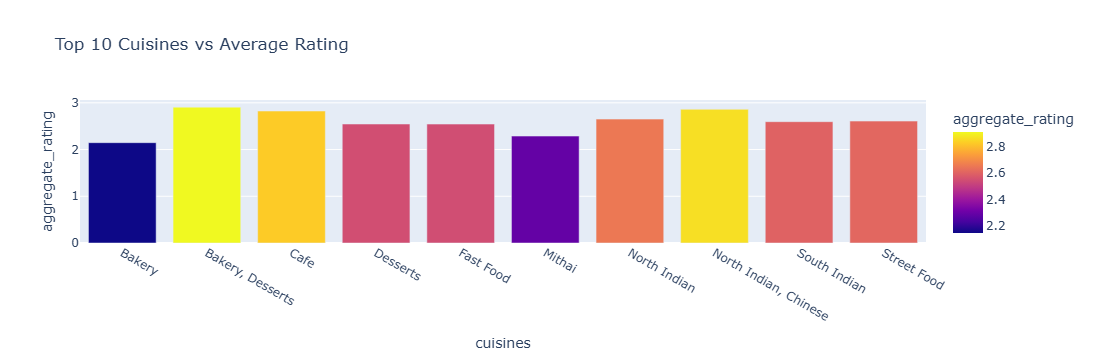

In [165]:
#cuisine vs rating
top_cuisines = df['cuisines'].value_counts().head(10).index
cuisine_rating = df_top.groupby('cuisines')['aggregate_rating'].mean().reset_index()
fig = px.bar(cuisine_rating,x='cuisines',y='aggregate_rating',color='aggregate_rating',title='Top 10 Cuisines vs Average Rating',color_continuous_scale='plasma')
fig.show()

- Bakery & Desserts and North Indian + Chinese cuisines have the **highest average ratings** among the top cuisines.
- Café and South Indian cuisines also perform well with relatively high ratings.
- Fast Food and Desserts have moderate ratings, indicating average customer satisfaction.
- Mithai and Bakery have comparatively **lower average ratings**.
- Differences in ratings across cuisines are **not very large**, showing relatively consistent performance.
- Overall, no single cuisine dominates in ratings, suggesting that **quality matters more than cuisine type**.

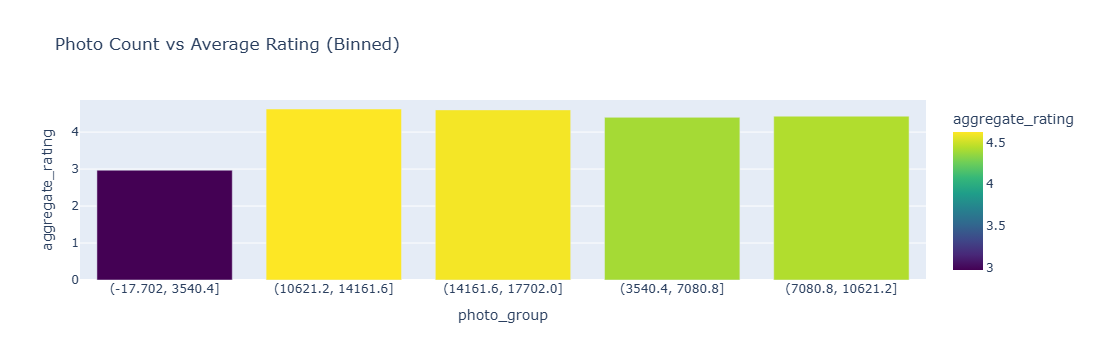

In [159]:
#photocount vs rating
df['photo_group'] = pd.cut(df['photo_count'], bins=5).astype(str)
photo_avg = df.groupby('photo_group')['aggregate_rating'].mean().reset_index()
fig = px.bar(photo_avg,x='photo_group',y='aggregate_rating',color='aggregate_rating',title='Photo Count vs Average Rating (Binned)',color_continuous_scale='viridis')
fig.show()

- Restaurants with higher photo counts tend to have **higher average ratings**.
- The lowest photo count group shows comparatively **lower ratings**, indicating less engagement.
- Mid to high photo count groups consistently have ratings above **4.0**, suggesting better customer perception.
- This indicates that restaurants with more photos are likely more **visually appealing and engaging**.
- However, after a certain level, the increase in rating becomes stable, showing a **plateau effect**.
- Overall, photo count has a **positive but moderate impact** on ratings.

**MULTIVARIATE ANALYSIS**

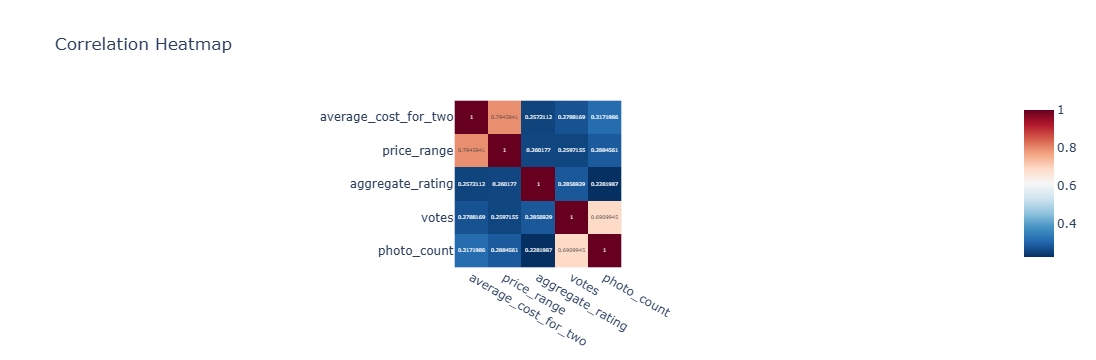

In [169]:
corr = df.corr(numeric_only=True)
fig = px.imshow(corr,text_auto=True,color_continuous_scale='RdBu_r',title="Correlation Heatmap")
fig.show()

- There is a strong positive correlation between **average_cost_for_two and price_range (~0.79)**, indicating consistent pricing categorization.
- **Votes and photo_count (~0.69)** show a strong relationship, suggesting popular restaurants tend to have more photos.
- **Aggregate_rating has weak correlations** with most variables, including votes, price range, and photo count.
- This indicates that ratings are **not strongly influenced by a single factor**.
- Most relationships are weak to moderate, showing that multiple factors together influence restaurant performance.
- Overall, the heatmap suggests that **customer satisfaction is multi-dimensional** and not dependent on one variable alone.

## Summary

- The dataset shows that most restaurants have ratings between **3.0 and 4.5**, indicating generally good customer satisfaction.
- Metro cities like **Bangalore, Mumbai, and Chennai** have the highest number of restaurants, reflecting strong market demand.
- **North Indian and Fast Food cuisines** dominate the market in terms of availability.
- Majority of restaurants fall under **low to mid price range**, indicating affordability-focused demand.
- Votes and photo counts are highly skewed, with only a few restaurants receiving very high engagement.
- Features like Wi-Fi, Alcohol, and Photo availability show only a **moderate impact** on ratings.
- Correlation analysis reveals that **no single factor strongly influences ratings**, indicating a multi-factor dependency.

---

## Recommendations

### For Restaurant Owners

- Focus on **food quality and service consistency**, as they are the primary drivers of ratings.
- Maintain an **active online presence** by adding photos and engaging customers to increase visibility.
- Offer online delivery and convenient services to improve customer reach.
- While pricing is important, ensure **value for money** rather than just increasing prices.
- If expanding as a chain, maintain **consistent quality across outlets**.

---

### For Zomato / Users

- Users should not rely only on price or popularity; instead, consider **ratings along with reviews and features**.
- Zomato can improve recommendations by focusing more on **quality-based ranking** rather than just popularity.
- Encouraging users to upload photos and reviews can improve platform engagement and decision-making.
- Adding more **time-based data** (reviews over time) can help in identifying trends.

---

## Conclusion

- The analysis shows that restaurant success depends on a **combination of factors** rather than a single variable.
- While factors like price, votes, and features have some influence, **they do not strongly determine ratings**.
- Customer satisfaction is primarily driven by **quality, consistency, and overall experience**.
- Restaurants that balance affordability, service, and engagement are more likely to succeed.
- Overall, the study highlights that **data-driven insights can help businesses improve performance and customer experience**.